In [2]:
"""
Board Keypoint Prediction Training Notebook

This notebook trains a YOLO Pose model to predict the 9 hex center keypoints on board game boards.
It includes dataset preparation, train/val/test splitting, model training, and visualization.

Author: NCSU - Fall 2025 Board Game Project
"""

# ============================================================================
# IMPORTS
# ============================================================================

import os
import random
import shutil
from pathlib import Path
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO  # YOLOv8 pose estimation
import torch

In [4]:
# ============================================================================
# STEP 1: SETUP PATHS AND CONFIGURATION
# ============================================================================

# Base directory paths
BASE_DIR = Path("/mnt/e/NCSU/Fall_2025/Board Game/board_keypoint_prediction")

# Dataset directories (augmented data from keypoint_dataaug.py)
DATASET_DIR = BASE_DIR / "yolo_keypoint_dataset"
IMAGES_DIR = DATASET_DIR / "images_aug"  # Augmented images
LABELS_DIR = DATASET_DIR / "labels_aug"  # Augmented YOLO pose labels

# Output directory for train/val/test split
YOLO_DATASET_DIR = BASE_DIR / "yolo_pose_dataset"

print(f"📁 Dataset location: {DATASET_DIR}")
print(f"📁 Output location: {YOLO_DATASET_DIR}")

📁 Dataset location: /mnt/e/NCSU/Fall_2025/Board Game/board_keypoint_prediction/yolo_keypoint_dataset
📁 Output location: /mnt/e/NCSU/Fall_2025/Board Game/board_keypoint_prediction/yolo_pose_dataset


In [5]:
# ============================================================================
# STEP 2: DEFINE KEYPOINT AND CLASS CONFIGURATION
# ============================================================================

# Number of hex center keypoints on the board
KEYPOINTS = 9

# Keypoint names (must match Label Studio annotations)
KEYPOINT_NAMES = [f"Hex{i+1}" for i in range(KEYPOINTS)]

# Class names (only one class: board)
CLASS_NAMES = ["board"]

print(f"🎯 Keypoints: {KEYPOINT_NAMES}")
print(f"📦 Classes: {CLASS_NAMES}")

🎯 Keypoints: ['Hex1', 'Hex2', 'Hex3', 'Hex4', 'Hex5', 'Hex6', 'Hex7', 'Hex8', 'Hex9']
📦 Classes: ['board']


In [6]:
# ============================================================================
# STEP 3: CREATE TRAIN/VAL/TEST SPLIT
# ============================================================================

# Get all image files from the augmented dataset
image_files = sorted([f for f in IMAGES_DIR.glob("*.jpg")])
image_names = [img.stem for img in image_files]

# Shuffle with fixed seed for reproducibility
random.seed(42)
random.shuffle(image_names)

# Calculate split sizes: 70% train, 20% val, 10% test
n_total = len(image_names)
n_train = int(0.7 * n_total)
n_val = int(0.2 * n_total)
n_test = n_total - n_train - n_val

# Split the data
train_names = image_names[:n_train]
val_names = image_names[n_train:n_train+n_val]
test_names = image_names[n_train+n_val:]

print(f"📊 Dataset Split:")
print(f"   Total images: {n_total}")
print(f"   Training:     {n_train} ({n_train/n_total*100:.1f}%)")
print(f"   Validation:   {n_val} ({n_val/n_total*100:.1f}%)")
print(f"   Testing:      {n_test} ({n_test/n_total*100:.1f}%)")

📊 Dataset Split:
   Total images: 510
   Training:     357 (70.0%)
   Validation:   102 (20.0%)
   Testing:      51 (10.0%)


In [ ]:
# ============================================================================
# STEP 4: CREATE YOLO DATASET DIRECTORY STRUCTURE
# ============================================================================

def create_yolo_structure():
    """
    Create the YOLO pose dataset directory structure.
    
    Structure:
        yolo_pose_dataset/
        ├── train/
        │   ├── images/
        │   └── labels/
        ├── val/
        │   ├── images/
        │   └── labels/
        └── test/
            ├── images/
            └── labels/
    """
    # Remove existing directory if present
    if YOLO_DATASET_DIR.exists():
        shutil.rmtree(YOLO_DATASET_DIR)
    
    # Create train/val/test subdirectories
    for split in ['train', 'val', 'test']:
        (YOLO_DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
        (YOLO_DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    print("✅ Created YOLO pose dataset directory structure.")

create_yolo_structure()

In [ ]:
# ============================================================================
# STEP 5: COPY FILES TO TRAIN/VAL/TEST DIRECTORIES
# ============================================================================

def copy_files_to_splits():
    """
    Copy images and labels to their respective train/val/test directories.
    """
    splits = {
        'train': train_names,
        'val': val_names,
        'test': test_names
    }
    
    for split_name, file_names in splits.items():
        print(f"Copying {len(file_names)} files to {split_name}...")
        for file_name in file_names:
            # Copy image
            src_img = IMAGES_DIR / f"{file_name}.jpg"
            dst_img = YOLO_DATASET_DIR / split_name / 'images' / f"{file_name}.jpg"
            shutil.copy2(src_img, dst_img)
            
            # Copy label
            src_label = LABELS_DIR / f"{file_name}.txt"
            dst_label = YOLO_DATASET_DIR / split_name / 'labels' / f"{file_name}.txt"
            shutil.copy2(src_label, dst_label)
    
    print("✅ Copied images and labels to splits.")

copy_files_to_splits()

In [ ]:
# ============================================================================
# STEP 6: CREATE YOLO POSE CONFIGURATION FILE (dataset.yaml)
# ============================================================================

def create_yolo_pose_config():
    """
    Create YOLO pose dataset configuration file.
    
    The dataset.yaml file contains:
    - Dataset path
    - Paths to train/val/test splits
    - Class names
    - Keypoint shape: [num_keypoints, 3] where 3 = (x, y, visibility)
    - Keypoint names
    """
    config = {
        'path': str(YOLO_DATASET_DIR.resolve()),  # Absolute path to dataset
        'train': 'train/images',  # Relative path to training images
        'val': 'val/images',      # Relative path to validation images
        'test': 'test/images',    # Relative path to test images
        'names': CLASS_NAMES,     # List of class names
        'kpt_shape': [KEYPOINTS, 3],  # Keypoint shape: [9 keypoints, (x, y, visibility)]
        'keypoints': KEYPOINT_NAMES   # Names for each keypoint
    }
    
    config_file = YOLO_DATASET_DIR / 'dataset.yaml'
    with open(config_file, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    
    print(f"✅ Created YOLO pose configuration file: {config_file}")
    return config_file

config_file = create_yolo_pose_config()

In [7]:
# ============================================================================
# STEP 7: VISUALIZATION HELPER FUNCTION
# ============================================================================

def plot_pose_sample(img_path, label_path, ax, keypoint_names=KEYPOINT_NAMES):
    """
    Visualize a single image with its keypoint annotations.
    
    Args:
        img_path: Path to the image file
        label_path: Path to the YOLO pose label file
        ax: Matplotlib axis to plot on
        keypoint_names: List of keypoint names for labels
    """
    # Load and convert image to RGB
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    
    # Read label file and parse keypoints
    with open(label_path, 'r') as f:
        line = f.readline().strip().split()

        # Extract keypoint coordinates and visibility flags
        # Format: class bbox_x bbox_y bbox_w bbox_h kp1_x kp1_y kp1_v ...
        kpts = []
        vis = []
        for i in range(5, len(line), 3):  # Start from index 5 (after bbox)
            if i+2 < len(line):
                kpts.extend([float(line[i]), float(line[i+1])])
                vis.append(int(line[i+2]))
    
    # Plot keypoints
    h, w = img.shape[:2]
    for i in range(KEYPOINTS):
        x = kpts[2*i] * w  # Convert normalized to pixel coordinates
        y = kpts[2*i+1] * h
        v = vis[i]
        
        # Only plot visible keypoints (v > 0)
        if v > 0:
            ax.scatter(x, y, s=60, c='red', marker='o')
            ax.text(x, y, keypoint_names[i], color='blue', fontsize=10)
    
    ax.set_title(f"{img_path.name}")
    ax.axis('off')

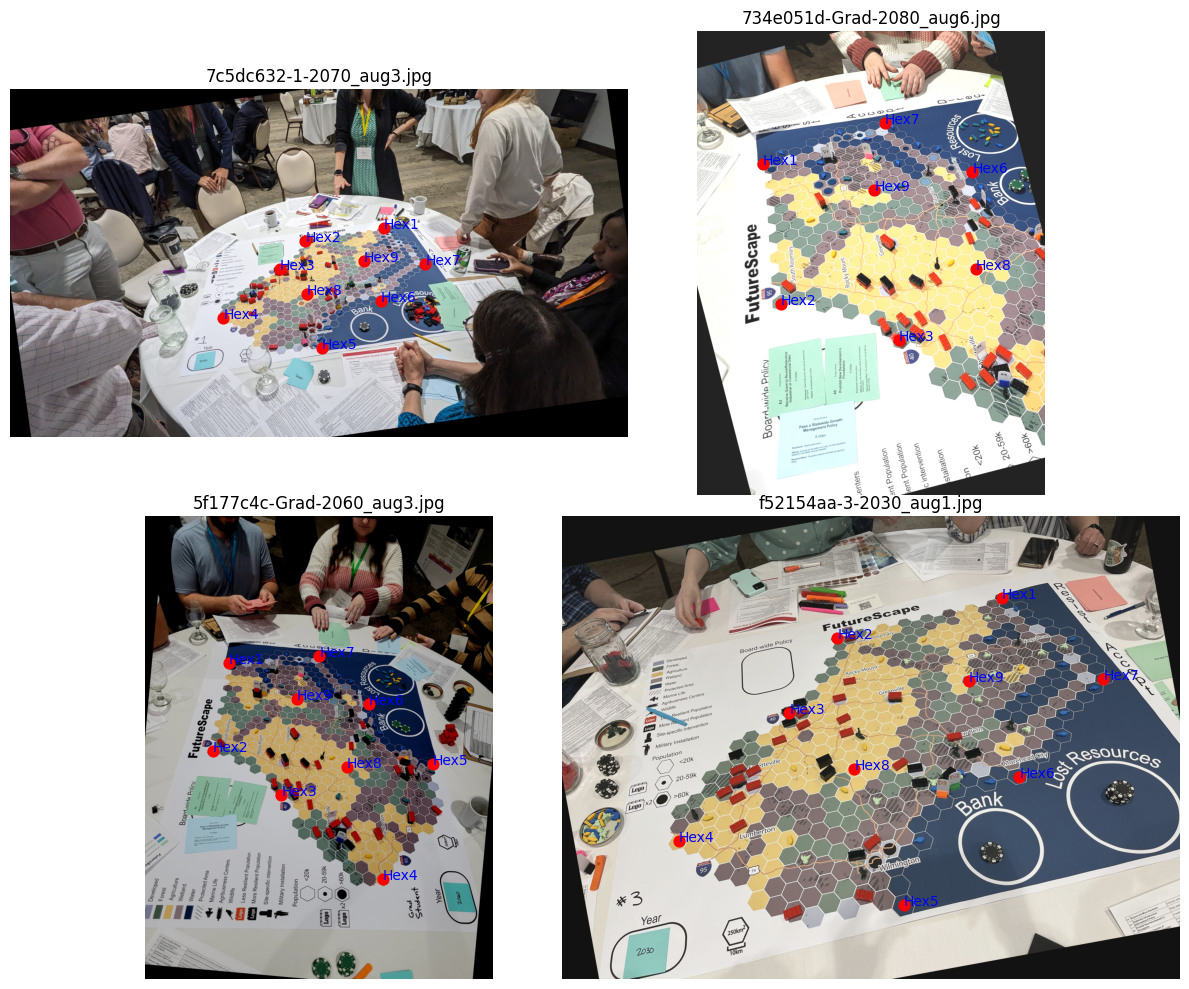

✅ Sample visualization completed. Red dots show keypoints.


In [8]:
# ============================================================================
# STEP 8: VISUALIZE TRAINING SAMPLES
# ============================================================================

# Sample 4 random training images for visualization
sample_names = random.sample(train_names, min(4, len(train_names)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, sample_name in enumerate(sample_names):
    img_path = YOLO_DATASET_DIR / 'train' / 'images' / f"{sample_name}.jpg"
    label_path = YOLO_DATASET_DIR / 'train' / 'labels' / f"{sample_name}.txt"
    plot_pose_sample(img_path, label_path, axes[i])

plt.tight_layout()
plt.show()
print("✅ Sample visualization completed. Red dots show keypoints.")

In [ ]:
# ============================================================================
# STEP 9: TRAIN YOLO POSE MODEL
# ============================================================================

# Check for GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Training on: {device.upper()}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Load pre-trained YOLOv8 pose model
# Options: yolov8n-pose.pt (fastest), yolov8s-pose.pt, yolov8m-pose.pt (most accurate)
model = YOLO('yolov8m-pose.pt')

# Training hyperparameters
EPOCHS = 40        # Number of training epochs
IMAGE_SIZE = 416   # Input image size (reduce if OOM)
BATCH_SIZE = 8     # Batch size (reduce if OOM)

print(f"\n⚙️  Training Configuration:")
print(f"   Model: YOLOv8m-pose")
print(f"   Epochs: {EPOCHS}")
print(f"   Image size: {IMAGE_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Device: {device}")

# Train the model
results = model.train(
    data=str(config_file),       # Path to dataset.yaml
    epochs=EPOCHS,               # Number of training epochs
    imgsz=IMAGE_SIZE,           # Input image size
    batch=BATCH_SIZE,           # Batch size
    device=device,              # Training device (cuda/cpu)
    name="board_pose",          # Training run name
    exist_ok=True,              # Allow overwriting
    verbose=True,               # Print training progress
    workers=2,                  # Number of data loading workers
    single_cls=True,            # Single class detection
)

print(f"\n✅ Model saved to: {results.save_dir}")

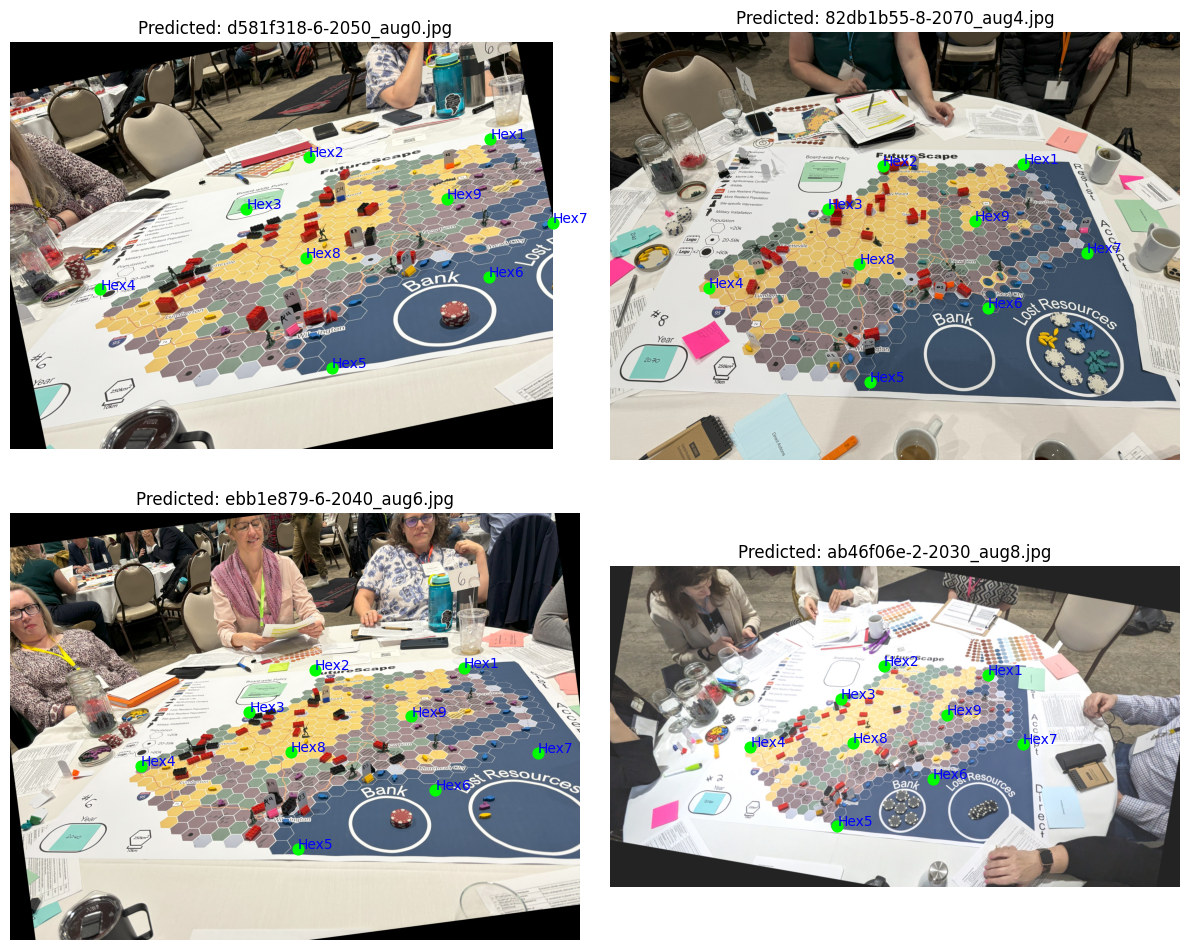

✅ Inference and visualization completed. Lime dots show predicted keypoints.


In [7]:
# ============================================================================
# STEP 10: RUN INFERENCE ON TEST SAMPLES
# ============================================================================

# Load the best trained model
best_model_path = Path("runs/pose/board_pose/weights/best.pt")
pose_model = YOLO(str(best_model_path))

# Sample 4 random test images
sample_names = random.sample(test_names, min(4, len(test_names)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, sample_name in enumerate(sample_names):
    img_path = YOLO_DATASET_DIR / 'test' / 'images' / f"{sample_name}.jpg"
    
    # Load and display image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Predicted: {img_path.name}")
    axes[i].axis('off')

    # Run inference
    results = pose_model(str(img_path), verbose=False)
    result = results[0]
    h, w = img.shape[:2]

    # Plot predicted keypoints
    if hasattr(result, "keypoints") and result.keypoints is not None:
        kpts = result.keypoints.xy[0]  # Keypoint coordinates
        confs = result.keypoints.conf[0]  # Confidence scores
        
        for j, (xy, conf) in enumerate(zip(kpts, confs)):
            x, y = xy.cpu().numpy()
            
            # Only plot keypoints with confidence > 0.2
            # if conf > 0.2:
            axes[i].scatter(x, y, s=60, c='lime', marker='o')
            axes[i].text(x, y, KEYPOINT_NAMES[j], color='blue', fontsize=10)
    else:
        axes[i].text(0.5, 0.5, "No keypoints detected", 
                    ha='center', va='center', transform=axes[i].transAxes, color='red')

plt.tight_layout()
plt.show()
print("✅ Inference and visualization completed. Lime dots show predicted keypoints.")

In [8]:
# ========================================================================
# STEP 11: EVALUATE POSE PREDICTIONS ON TEST SET
# ========================================================================

from pathlib import Path
import numpy as np

# Directory paths
TEST_IMG_DIR = YOLO_DATASET_DIR / 'test' / 'images'
TEST_LABEL_DIR = YOLO_DATASET_DIR / 'test' / 'labels'
PCK_THRESHOLDS = [5, 10, 20, 50]  # pixels

def load_yolo_keypoints(label_path, img_shape):
    """Load keypoints from YOLO pose label file and convert to pixel coordinates."""
    with open(label_path, 'r') as f:
        line = f.readline().strip().split()
        kpts = []
        for i in range(5, len(line), 3):
            if i+1 < len(line):
                kpts.append([float(line[i]), float(line[i+1])])
    h, w = img_shape[:2]
    kpts = np.array(kpts)
    kpts_pixel = kpts * np.array([w, h])
    return kpts_pixel

def euclidean_distances(gt_kps, pred_kps):
    return np.linalg.norm(gt_kps - pred_kps, axis=1)

def mean_euclidean_distance(distances):
    return float(np.mean(distances))

def median_euclidean_distance(distances):
    return float(np.median(distances))

def pck(distances, threshold):
    return float(np.mean(distances < threshold) * 100)

def per_keypoint_mean_error(all_distances):
    stacked = np.stack(all_distances, axis=0)
    return np.mean(stacked, axis=0)

# Evaluate all test images
all_distances = []
test_img_files = sorted(list(TEST_IMG_DIR.glob("*.jpg")))
for img_path in test_img_files:
    label_path = TEST_LABEL_DIR / (img_path.stem + ".txt")
    if not label_path.exists():
        print(f"Warning: No label for {img_path.name}, skipping.")
        continue

    # Load GT keypoints
    gt_kps = load_yolo_keypoints(label_path, cv2.imread(str(img_path)).shape)

    # Run model inference
    results = pose_model(str(img_path), verbose=False)
    result = results[0]
    if hasattr(result, "keypoints") and result.keypoints is not None:
        pred_kps = result.keypoints.xy[0].cpu().numpy()
    else:
        print(f"Warning: No keypoints predicted for {img_path.name}, skipping.")
        continue

    if gt_kps.shape != pred_kps.shape:
        print(f"Shape mismatch for {img_path.name}, skipping.")
        continue

    distances = euclidean_distances(gt_kps, pred_kps)
    all_distances.append(distances)

    print(f"\nImage: {img_path.name}")
    print(f"  Mean Distance   : {mean_euclidean_distance(distances):.2f} px")
    print(f"  Median Distance : {median_euclidean_distance(distances):.2f} px")
    for tau in PCK_THRESHOLDS:
        print(f"  PCK@{tau:<4}        : {pck(distances, tau):.1f}%")

# Overall metrics
if all_distances:
    all_dist_flat = np.concatenate(all_distances)
    num_imgs = len(all_distances)
    num_kps = len(all_distances[0])

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  Images evaluated         : {num_imgs}")
    print(f"  Keypoints per image      : {num_kps}")
    print(f"  Mean Distance            : {mean_euclidean_distance(all_dist_flat):.2f} px")
    print(f"  Median Distance          : {median_euclidean_distance(all_dist_flat):.2f} px")
    print(f"\n  {'Threshold':<12} {'% Correct':>10}   {'Images all-KP correct':>22}")
    print(f"  {'-'*48}")
    for tau in PCK_THRESHOLDS:
        pck_pct = pck(all_dist_flat, tau)
        imgs_all_correct = sum(np.all(d < tau) for d in all_distances)
        print(f"  PCK@{tau:<8} {pck_pct:>9.1f}%   {imgs_all_correct:>12} / {num_imgs}")

    per_kp = per_keypoint_mean_error(all_distances)
    print(f"\n  {'Keypoint':<12} {'Mean Error (px)':>16}")
    print(f"  {'-'*30}")
    for i, err in enumerate(per_kp):
        print(f"  KP {i:>2}        {err:>14.2f} px")
    print("="*60)
else:
    print("No valid predictions to evaluate.")


Image: 0123ccbd-9-2040_aug3.jpg
  Mean Distance   : 74.39 px
  Median Distance : 60.74 px
  PCK@5           : 0.0%
  PCK@10          : 0.0%
  PCK@20          : 0.0%
  PCK@50          : 33.3%

Image: 06339ca2-6-2030_aug2.jpg
  Mean Distance   : 88.02 px
  Median Distance : 85.82 px
  PCK@5           : 0.0%
  PCK@10          : 0.0%
  PCK@20          : 11.1%
  PCK@50          : 33.3%

Image: 06339ca2-6-2030_aug3.jpg
  Mean Distance   : 67.56 px
  Median Distance : 63.57 px
  PCK@5           : 0.0%
  PCK@10          : 11.1%
  PCK@20          : 11.1%
  PCK@50          : 44.4%

Image: 06339ca2-6-2030_aug5.jpg
  Mean Distance   : 101.42 px
  Median Distance : 106.32 px
  PCK@5           : 0.0%
  PCK@10          : 0.0%
  PCK@20          : 0.0%
  PCK@50          : 11.1%

Image: 06339ca2-6-2030_aug6.jpg
  Mean Distance   : 827.10 px
  Median Distance : 145.29 px
  PCK@5           : 0.0%
  PCK@10          : 0.0%
  PCK@20          : 0.0%
  PCK@50          : 11.1%

Image: 238dde48-3-2070_aug4.jpg
